In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
# Load dataset
df = pd.read_csv("credit_data.csv")

print(df.head())
print(df.shape)
print(df.info())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

In [3]:
print(df.head())
print(df.info())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

In [4]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


In [5]:
print("\nDuplicate rows:")
print(df.duplicated().sum())


Duplicate rows:
0


In [7]:
print("\nTarget distribution:")



Target distribution:


In [10]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


In [11]:
print("Duplicate rows:")
print(df.duplicated().sum())

Duplicate rows:
0


In [13]:
print("Target distribution:")
print(df.value_counts())

Target distribution:
Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  NumberOfDependents
1           1                 0.766127                              45   2                                     0.802982   9120.0         13                               0                        6                             0                                     2.0                   1
2           0                 0.957151                              40   0                                     0.121876   2600.0         4                                0                        0                             0                                     1.0                   1
3           0                 0.658180                              38   1                                     0.085113   3

In [15]:
print(df.value_counts())

Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  NumberOfDependents
1           1                 0.766127                              45   2                                     0.802982   9120.0         13                               0                        6                             0                                     2.0                   1
2           0                 0.957151                              40   0                                     0.121876   2600.0         4                                0                        0                             0                                     1.0                   1
3           0                 0.658180                              38   1                                     0.085113   3042.0         2      

In [20]:
# Step 11: Create a useful financial feature

df["DebtIncomeRatio"] = df["DebtRatio"]

print(df[["MonthlyIncome", "DebtRatio", "DebtIncomeRatio"]].head(10))

   MonthlyIncome    DebtRatio  DebtIncomeRatio
0         9120.0     0.802982         0.802982
1         2600.0     0.121876         0.121876
2         3042.0     0.085113         0.085113
3         3300.0     0.036050         0.036050
4        63588.0     0.024926         0.024926
5         3500.0     0.375607         0.375607
6            NaN  5710.000000      5710.000000
7         3500.0     0.209940         0.209940
8            NaN    46.000000        46.000000
9        23684.0     0.606291         0.606291


In [21]:
# Step 12: Handle missing values

print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill MonthlyIncome with median
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())

# Fill NumberOfDependents with median
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(
    df["NumberOfDependents"].median()
)

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
DebtIncomeRatio                             0
dtype: int64

Missing values after cleaning:
Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans

In [22]:
# Step 13: Select features and target

features = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents"
]

X = df[features]
y = df["SeriousDlqin2yrs"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150000, 10)
y shape: (150000,)


In [23]:
# Step 14: Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120000, 10)
Testing data: (30000, 10)


In [24]:
# Step 15: Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [25]:
# Step 16: Train Logistic Regression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [26]:
# Step 16: Train Logistic Regression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [30]:
# Step 18: Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
y_pred = model.predict(X_test_scaled)

# Probability of class 1
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print("========== CREDIT SCORING MODEL ==========")
print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1-Score  :", round(f1, 4))
print("ROC-AUC   :", round(roc_auc, 4))

========== CREDIT SCORING MODEL ==========
Accuracy  : 0.934
Precision : 0.5806
Recall    : 0.0449
F1-Score  : 0.0833
ROC-AUC   : 0.7143


Confusion Matrix:
[[27930    65]
 [ 1915    90]]


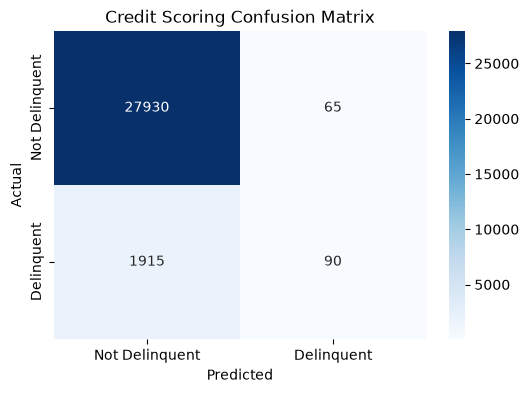

In [31]:
# Step 19: Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Delinquent", "Delinquent"],
    yticklabels=["Not Delinquent", "Delinquent"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Credit Scoring Confusion Matrix")

plt.show()

In [32]:
# Step 20: Classification Report

from sklearn.metrics import classification_report

print("Classification Report")
print("=====================")

report = classification_report(
    y_test,
    y_pred,
    target_names=["Not Delinquent", "Delinquent"],
    zero_division=0
)

print(report)

Classification Report
                precision    recall  f1-score   support

Not Delinquent       0.94      1.00      0.97     27995
    Delinquent       0.58      0.04      0.08      2005

      accuracy                           0.93     30000
     macro avg       0.76      0.52      0.52     30000
  weighted avg       0.91      0.93      0.91     30000



In [33]:
# Final Model Results

print("Credit Scoring Model - Final Results")
print("------------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Credit Scoring Model - Final Results
------------------------------------
Accuracy  : 0.9340
Precision : 0.5806
Recall    : 0.0449
F1-Score  : 0.0833
ROC-AUC   : 0.7143
